In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df = pd.read_csv("../data/cleaned_housing.csv")

In [3]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.shape

(545, 13)

In [5]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


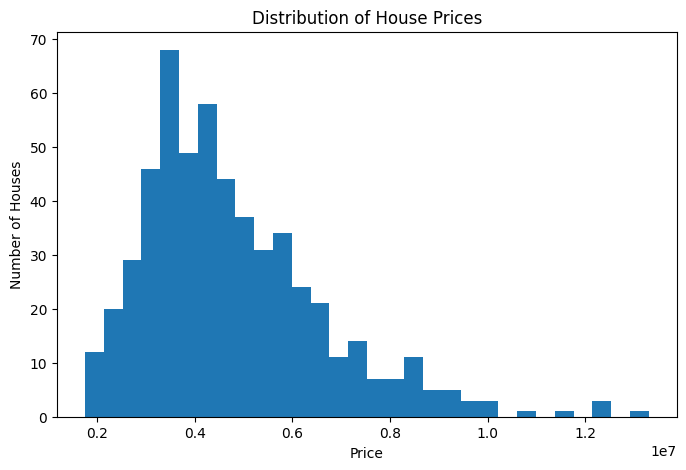

In [7]:
plt.figure(figsize=(8,5))

plt.hist(df["price"], bins=30)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")

plt.show()

In [8]:
numerical_cols = [
    'price',
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'parking'
]

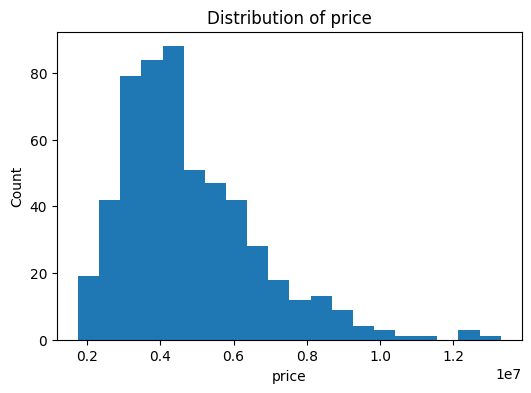

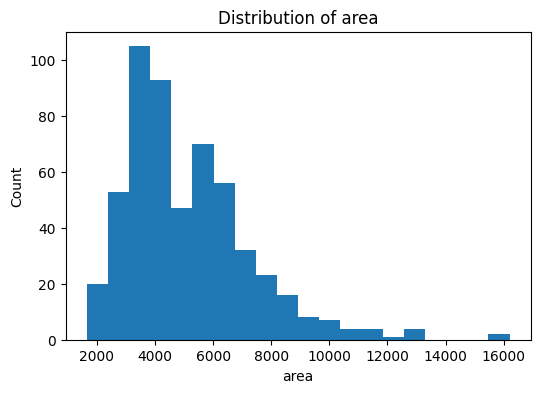

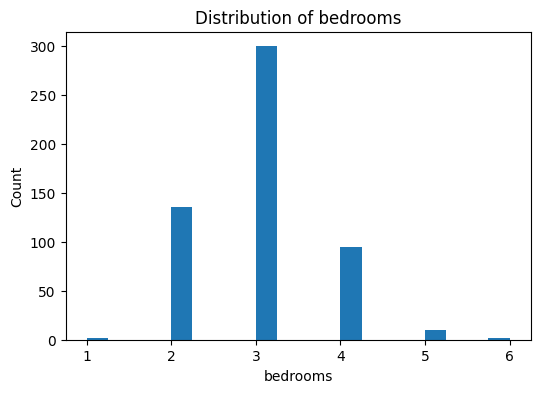

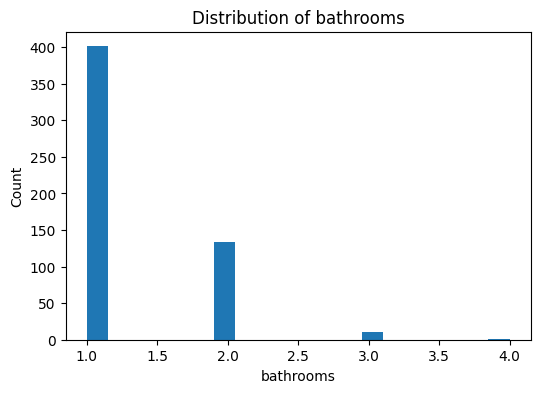

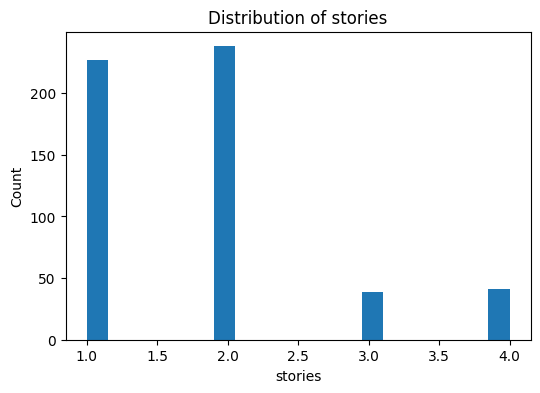

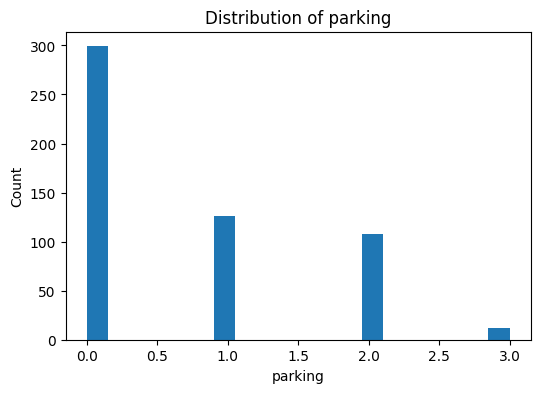

In [9]:
for column in numerical_cols:
    plt.figure(figsize=(6,4))

    plt.hist(df[column], bins=20)

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")

    plt.show()

In [10]:
categorical_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea',
    'furnishingstatus'
]

In [11]:
for column in categorical_cols:
    print(f"\n{column}")
    print(df[column].value_counts())


mainroad
mainroad
yes    468
no      77
Name: count, dtype: int64

guestroom
guestroom
no     448
yes     97
Name: count, dtype: int64

basement
basement
no     354
yes    191
Name: count, dtype: int64

hotwaterheating
hotwaterheating
no     520
yes     25
Name: count, dtype: int64

airconditioning
airconditioning
no     373
yes    172
Name: count, dtype: int64

prefarea
prefarea
no     417
yes    128
Name: count, dtype: int64

furnishingstatus
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


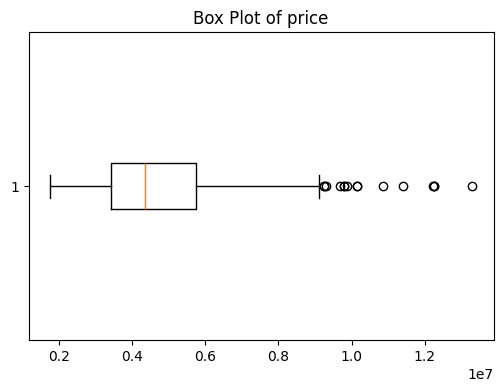

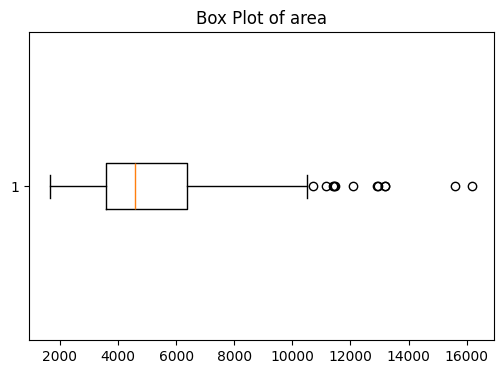

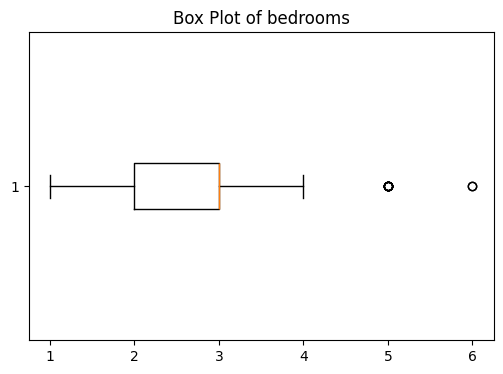

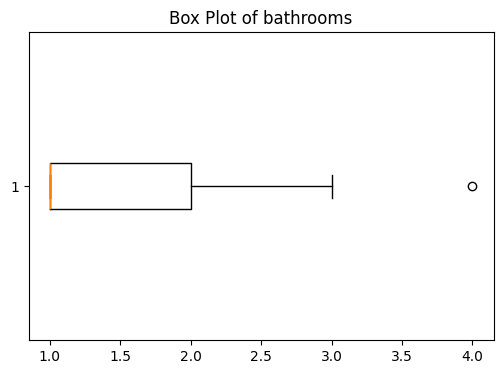

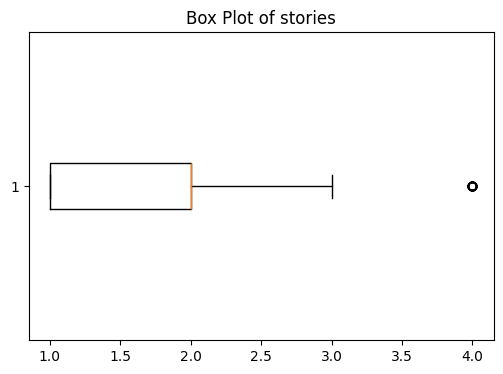

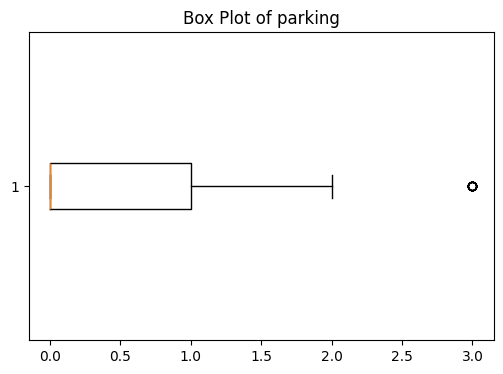

In [12]:
for column in numerical_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[column], vert=False)
    plt.title(f"Box Plot of {column}")
    plt.show()

In [14]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

correlation = numeric_df.corr()

correlation

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


In [15]:
fig = px.imshow(
    correlation,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    title="Correlation Heatmap"
)

fig.show()

In [16]:
fig = px.scatter(
    df,
    x="area",
    y="price",
    title="Area vs Price",
    color="furnishingstatus"
)

fig.show()

In [17]:
fig = px.box(
    df,
    x="furnishingstatus",
    y="price",
    color="furnishingstatus",
    title="Price by Furnishing Status"
)

fig.show()

In [18]:
fig = px.box(
    df,
    x="mainroad",
    y="price",
    color="mainroad",
    title="Price vs Main Road"
)

fig.show()

In [19]:
avg_price = df.groupby("bedrooms")["price"].mean().reset_index()

fig = px.bar(
    avg_price,
    x="bedrooms",
    y="price",
    title="Average Price by Bedrooms"
)

fig.show()

In [20]:
avg_story = df.groupby("stories")["price"].mean().reset_index()

fig = px.bar(
    avg_story,
    x="stories",
    y="price",
    title="Average Price by Stories"
)

fig.show()

In [21]:
df.describe().to_csv("../reports/eda_summary.csv")